# Across-session pupil position in the eye-anchored frame

**Question.** Some days the online gaze looks centered, others biased. Real gaze difference, or an
artifact of the online processing?

Pupil position *in the image* isn't comparable across days (each day is a different **crop**/zoom of a
fixed camera view; the head-fixed animal may sit slightly differently). So we express the pupil in an
**eye-anchored frame** from clicked landmarks: `u` runs corner-to-corner (−1 .. +1, 0 = centered),
invariant to crop/translation/zoom. We also run the **online tracker** (`get_pupil_online`) beside a
**robust ellipse** detector — agreement means the online tracker is faithful.

**Read-out** (`centered` vs `biased` groups): `u` differs → **real gaze bias**; `u` same though image
position differed → **crop/head/processing artifact**. Helpers in `eyevideo.py`.


In [1]:
import eyevideo as ev
ev.ANIMAL_DIR = "/mnt/at-storageB1_I/EyeVideo/AT-B1NO1"
print(len(ev.list_sessions()), "sessions available")


184 sessions available


## 1. Click eye landmarks for each date (only if missing)
Do one date at a time: set `d`, run the widget cell (clicks only if that date has no landmarks),
left-click ≥5 points, right-click to undo, then `clk.save()`. Repeat for every date.
No-click fallback: `ev.show_mean_grid(d)` then `ev.set_landmarks(d, [(x,y), ...])`.


In [ ]:
%matplotlib widget
d = "2025-08-15"                       # <- change per date
clk = ev.clicker_if_missing(d)         # clicks only if this date has no landmarks yet


In [ ]:
clk and clk.save()                     # run after clicking; repeat the two cells for the next date
%matplotlib inline
print("landmarks on file:", sorted(ev.LANDMARKS))


## 2. QC: tracking per date
Ellipse should hug the pupil; markers coincide; agreement scatter on the identity line.


In [ ]:
ev.show_tracking_examples(sorted(ev.LANDMARKS), k=5)


In [ ]:
ev.tracker_agreement(sorted(ev.LANDMARKS), n=200)


## 2b. Does the tracker discrepancy differ between conditions?
Ellipse-x vs online-x and ellipse-y vs online-y, split by condition, plus the discrepancy
delta = online - ellipse per group. If delta is similar across conditions, a tracking artifact
can't explain a group difference; if delta differs, it could contribute.


In [ ]:
_ = ev.compare_agreement(centered_dates, biased_dates, n=200)


## 3. Compare conditions: centered vs biased
Density histograms of pupil `u` (eye frame) per condition for both trackers (`bins=` controls
granularity). Stats: two groups → Welch t-test, >2 → one-way ANOVA. The **valid** test runs on
per-session median `u` (n = #days, needs ≥2 days/condition); a frame-level test is also printed
but is pseudo-replicated (correlated frames) and only illustrative.

For >2 groups use `ev.compare_conditions(conditions={'name': [dates], ...})`.


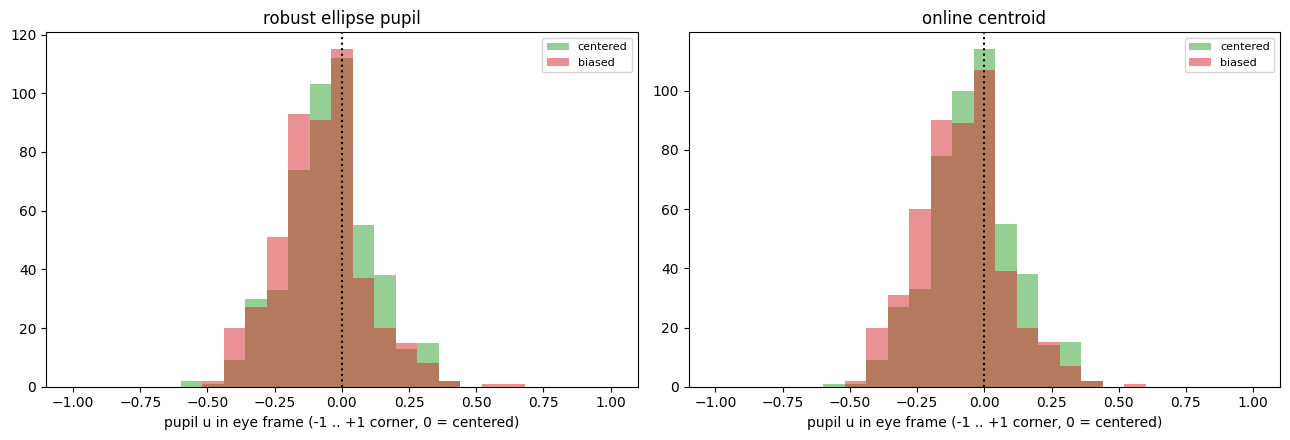

cond      date         u_robust u_online     n
centered  2026-05-27     -0.043   -0.042   487
biased    2026-06-04     -0.078   -0.082   483
POOLED centered  robust u median=-0.043  online u median=-0.042  N=487
POOLED biased    robust u median=-0.078  online u median=-0.082  N=483


In [2]:
centered_dates = ['2025-08-19']
biased_dates   = ['2025-08-15', '2026-06-04']
res = ev.compare_conditions(centered_dates, biased_dates, n=120, bins=60)
